In [20]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

def solve_fem_1d(g_func, a, b_dom, ya, yb, N):
    x = np.linspace(a, b_dom, N + 1)
    h = (b_dom - a) / N

    # Matriz de rigidez
    A = np.zeros((N + 1, N + 1))
    for i in range(N):
        A[i, i]     += 1 / h
        A[i, i + 1] -= 1 / h
        A[i + 1, i] -= 1 / h
        A[i + 1, i + 1] += 1 / h

  #Vector b
    b_vec = np.zeros(N + 1)
    for i in range(N):
        x1, x2 = x[i], x[i + 1]

        # Se optimizaron las integrales propuestas en clase, añadiendo ademas el producto con la funcion g(x).
        int_izq  = integrate.quad(lambda t: g_func(t) * (x2 - t) / h, x1, x2)[0]
        int_der = integrate.quad(lambda t: g_func(t) * (t - x1) / h, x1, x2)[0]

        b_vec[i]     += int_izq
        b_vec[i + 1] += int_der

    # 3. Aplicación limpia de Condiciones de Dirichlet (Sustitución directa)
    # Extremidad izquierda: y(a) = ya
    A[0, :] = 0.0
    A[0, 0] = 1.0
    b_vec[0] = ya

    # Extremidad derecha: y(b) = yb
    A[N, :] = 0.0
    A[N, N] = 1.0
    b_vec[N] = yb

# Ajuste de nodos adyacentes para mantener la consistencia
    for i in range(1, N):
        b_vec[i] -= A[i, 0] * ya + A[i, N] * yb
        A[i, 0] = 0.0
        A[i, N] = 0.0

    # Resolver el sistema
    y_sol = np.linalg.solve(A, b_vec)
    return x, y_sol


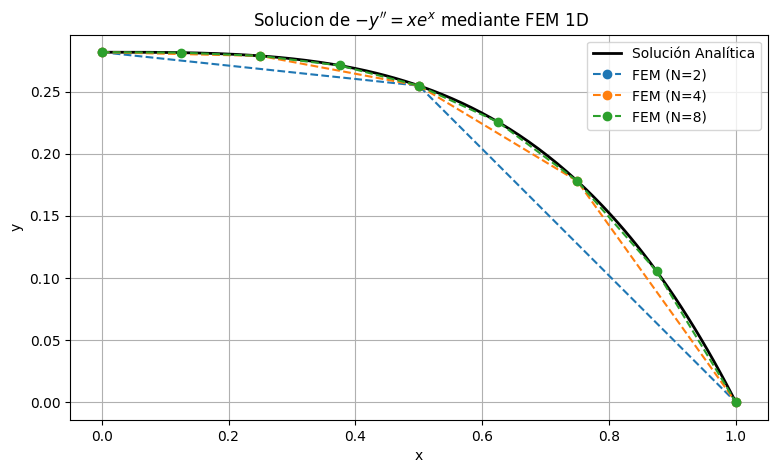

In [21]:
# PARÁMETROS

g = lambda x: x * np.exp(x)

a, b_domain = 0.0, 1.0
ya = 3 - np.exp(1)  # y(0) = 3 - e ≈ 0.2817
yb = 0.0            # y(1) = 0

#--------------------------------------
x_good = np.linspace(a, b_domain, 200)

def y_exact(x):
     return 1- np.e - (np.exp(x)) * (x-2) -x


##GRAFICACIÓN

plt.figure(figsize=(9, 5))

x_fine = np.linspace(a, b, 200)
plt.plot(x_good, y_exact(x_good), 'k-', label='Solución Analítica', linewidth=2)


elementos = [2, 4, 8]
for N in elementos:
    x_fem, y_fem = solve_fem_1d(g, a, b_domain, ya, yb, N)
    plt.plot(x_fem, y_fem, 'o--', label=f'FEM (N={N})')

plt.title(r" Solucion de $-y'' = x e^x$ mediante FEM 1D")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()